# Luna Maharjan 2418109
# Part II: Image Classification  Sign Language Detection
**AI & Machine Learning**

**Dataset:**  Sign Language (38 Classes, 0–37)




##Install and Import Required Libraries

In [ ]:
# If running on Google Colab, mount Google Drive first
# from google.colab import drive
# drive.mount('/content/drive')

# Install any missing libraries if needed
# !pip install tensorflow matplotlib scikit-learn seaborn

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

print('TensorFlow Version:', tf.__version__)
print('Keras Version:', keras.__version__)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print('GPUs Available:', gpus if gpus else 'None – using CPU')

TensorFlow Version: 2.20.0
Keras Version: 3.13.2
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Step 1: Dataset Configuration

In [ ]:
TRAIN_DIR = '/content/drive/MyDrive/AI FINAL ASSESSMENT/Train'
TEST_DIR  = '/content/drive/MyDrive/AI FINAL ASSESSMENT/Test'

# Hyperparameters
IMG_HEIGHT   = 64
IMG_WIDTH    = 64
BATCH_SIZE   = 64
NUM_CLASSES  = 38
EPOCHS_BASE  = 15
EPOCHS_DEEP  = 15
EPOCHS_TL    = 10
RANDOM_SEED  = 42

CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]  # '0' to '37'

print(f'Image Size     : {IMG_HEIGHT} x {IMG_WIDTH}')
print(f'Batch Size     : {BATCH_SIZE}')
print(f'Number of Classes: {NUM_CLASSES}')
print(f'Class Names    : {CLASS_NAMES}')

Image Size     : 64 x 64
Batch Size     : 64
Number of Classes: 38
Class Names    : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']



## Step 1.5: Corrupted Image Detection & Removal


In [ ]:
# =====================================================================
# CORRUPTED IMAGE SCANNER & REMOVER
# Scans TRAIN_DIR and TEST_DIR for bad images before training
# =====================================================================

from PIL import Image, UnidentifiedImageError
import imghdr

# Supported image extensions
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'}


def scan_and_remove_corrupted(root_dir, remove=True, verbose=True):
    """
    Scans all image files under root_dir recursively.
    Detects corrupted, empty, truncated, or non-image files.

    Parameters:
        root_dir (str)  : Path to the dataset folder (train or test).
        remove   (bool) : If True, deletes the corrupted files from disk.
        verbose  (bool) : If True, prints details of each corrupted file.

    Returns:
        dict: Summary with counts of scanned, corrupted, and removed files.
    """
    total_scanned   = 0
    corrupted_files = []
    skipped_ext     = []

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for fname in filenames:
            fpath = os.path.join(dirpath, fname)
            ext   = os.path.splitext(fname)[1].lower()

            # Skip non-image files silently
            if ext not in VALID_EXTENSIONS:
                skipped_ext.append(fpath)
                continue

            total_scanned += 1
            reason = None

            # ── Check 1: Zero-byte / empty file ──────────────────
            if os.path.getsize(fpath) == 0:
                reason = 'Empty file (0 bytes)'

            # ── Check 2: PIL cannot open/verify the image ─────────
            if reason is None:
                try:
                    with Image.open(fpath) as img:
                        img.verify()   # Checks file integrity without loading pixels
                except (UnidentifiedImageError, Exception) as e:
                    reason = f'PIL verify failed: {str(e)[:80]}'

            # ── Check 3: Re-open and fully load pixels ────────────
            # img.verify() closes the file; need to re-open for pixel check
            if reason is None:
                try:
                    with Image.open(fpath) as img:
                        img_converted = img.convert('RGB')  # Force RGB conversion
                        img_converted.load()                # Actually decode pixels
                except Exception as e:
                    reason = f'Pixel load failed: {str(e)[:80]}'

            # ── Check 4: imghdr magic-byte validation ─────────────
            if reason is None:
                detected_type = imghdr.what(fpath)
                if detected_type is None:
                    reason = 'imghdr could not identify image type (invalid magic bytes)'

            # ── Log and optionally delete ─────────────────────────
            if reason:
                corrupted_files.append((fpath, reason))
                if verbose:
                    print(f'  [CORRUPTED] {fpath}')
                    print(f'              Reason: {reason}')
                if remove:
                    try:
                        os.remove(fpath)
                    except Exception as del_err:
                        print(f'              [WARNING] Could not delete: {del_err}')

    # ── Summary ───────────────────────────────────────────────────
    summary = {
        'directory'       : root_dir,
        'total_scanned'   : total_scanned,
        'corrupted_found' : len(corrupted_files),
        'removed'         : len(corrupted_files) if remove else 0,
        'skipped_non_img' : len(skipped_ext),
        'healthy_images'  : total_scanned - len(corrupted_files),
        'corrupted_list'  : corrupted_files
    }
    return summary


# ── Run scanner on TRAIN directory ───────────────────────────────
print('=' * 60)
print('  SCANNING TRAIN DIRECTORY FOR CORRUPTED IMAGES')
print('=' * 60)
train_scan = scan_and_remove_corrupted(TRAIN_DIR, remove=True, verbose=True)

print('\n' + '=' * 60)
print('  SCANNING TEST DIRECTORY FOR CORRUPTED IMAGES')
print('=' * 60)
test_scan  = scan_and_remove_corrupted(TEST_DIR, remove=True, verbose=True)

  SCANNING TRAIN DIRECTORY FOR CORRUPTED IMAGES

  SCANNING TEST DIRECTORY FOR CORRUPTED IMAGES


In [ ]:


def print_scan_report(scan_result):
    d = scan_result
    print(f"\n{'='*55}")
    print(f"  Scan Report: {d['directory']}")
    print(f"{'='*55}")
    print(f"  Total images scanned    : {d['total_scanned']}")
    print(f"  Healthy images          : {d['healthy_images']}")
    print(f"  Corrupted files found   : {d['corrupted_found']}")
    print(f"  Corrupted files removed : {d['removed']}")
    print(f"  Non-image files skipped : {d['skipped_non_img']}")
    if d['corrupted_found'] == 0:
        print(f"  Status                  : ✅ All images are healthy!")
    else:
        print(f"  Status                  : ⚠️  {d['corrupted_found']} corrupted file(s) removed.")
        print(f"\n  Corrupted file details:")
        for fpath, reason in d['corrupted_list']:
            print(f"    - {os.path.basename(fpath)} | {reason}")
    print(f"{'='*55}")


print_scan_report(train_scan)
print_scan_report(test_scan)

total_removed = train_scan['removed'] + test_scan['removed']
print(f"\n✅ Dataset cleaned. Total corrupted images removed: {total_removed}")
print("   Proceeding to data analysis and model training...")


  Scan Report: /content/drive/MyDrive/AI FINAL ASSESSMENT/Train
  Total images scanned    : 10792
  Healthy images          : 10792
  Corrupted files found   : 0
  Corrupted files removed : 0
  Non-image files skipped : 0
  Status                  : ✅ All images are healthy!

  Scan Report: /content/drive/MyDrive/AI FINAL ASSESSMENT/Test
  Total images scanned    : 3
  Healthy images          : 3
  Corrupted files found   : 0
  Corrupted files removed : 0
  Non-image files skipped : 0
  Status                  : ✅ All images are healthy!

✅ Dataset cleaned. Total corrupted images removed: 0
   Proceeding to data analysis and model training...


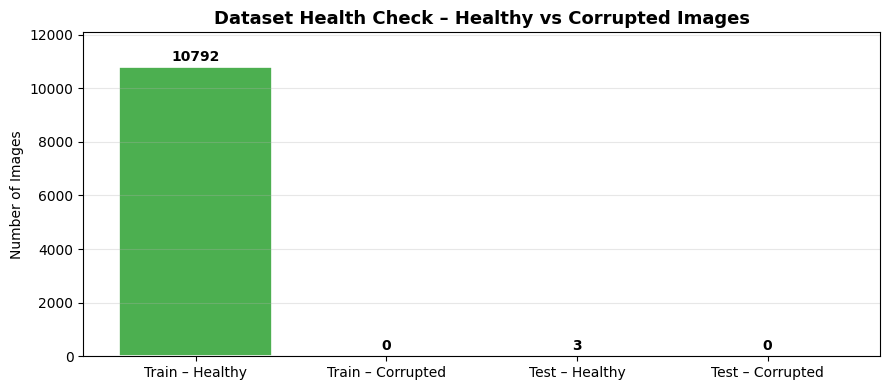

Corruption scan chart saved as corruption_scan_report.png


In [ ]:
# =====================================================================
# OPTIONAL: VISUALIZE CORRUPTED FILES SUMMARY AS BAR CHART
# =====================================================================

labels  = ['Train – Healthy', 'Train – Corrupted', 'Test – Healthy', 'Test – Corrupted']
values  = [
    train_scan['healthy_images'],
    train_scan['corrupted_found'],
    test_scan['healthy_images'],
    test_scan['corrupted_found']
]
colors  = ['#4CAF50', '#F44336', '#4CAF50', '#F44336']

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(values)*0.01,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Dataset Health Check – Healthy vs Corrupted Images', fontsize=13, fontweight='bold')
plt.ylabel('Number of Images')
plt.ylim(0, max(values) * 1.12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('corruption_scan_report.png', dpi=150, bbox_inches='tight')
plt.show()

print('Corruption scan chart saved as corruption_scan_report.png')


##Section 1: Data Understanding, Analysis, Visualization & Cleaning

### 1.1 Dataset Overview

In [ ]:
# Count images per class in training set
class_counts = {}
total_train  = 0

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count
        total_train += count

print('=' * 50)
print('         DATASET SUMMARY')
print('=' * 50)
print(f'Dataset      : Bengali Sign Language Detection')
print(f'Total Classes: {len(class_counts)}')
print(f'Total Training Images: {total_train}')
print('=' * 50)
print('\nPer-Class Image Count:')
for cls, cnt in sorted(class_counts.items(), key=lambda x: int(x[0])):
    print(f'  Class {cls:>3} : {cnt} images')

         DATASET SUMMARY
Dataset      : Bengali Sign Language Detection
Total Classes: 38
Total Training Images: 10792

Per-Class Image Count:
  Class   0 : 286 images
  Class   1 : 287 images
  Class   2 : 291 images
  Class   3 : 279 images
  Class   4 : 239 images
  Class   5 : 287 images
  Class   6 : 284 images
  Class   7 : 282 images
  Class   8 : 290 images
  Class   9 : 285 images
  Class  10 : 291 images
  Class  11 : 284 images
  Class  12 : 277 images
  Class  13 : 279 images
  Class  14 : 270 images
  Class  15 : 287 images
  Class  16 : 291 images
  Class  17 : 286 images
  Class  18 : 287 images
  Class  19 : 288 images
  Class  20 : 286 images
  Class  21 : 286 images
  Class  22 : 293 images
  Class  23 : 285 images
  Class  24 : 290 images
  Class  25 : 287 images
  Class  26 : 285 images
  Class  27 : 286 images
  Class  28 : 284 images
  Class  29 : 285 images
  Class  30 : 285 images
  Class  31 : 288 images
  Class  32 : 281 images
  Class  33 : 288 images
  Class

### 1.2 Class Distribution Visualization

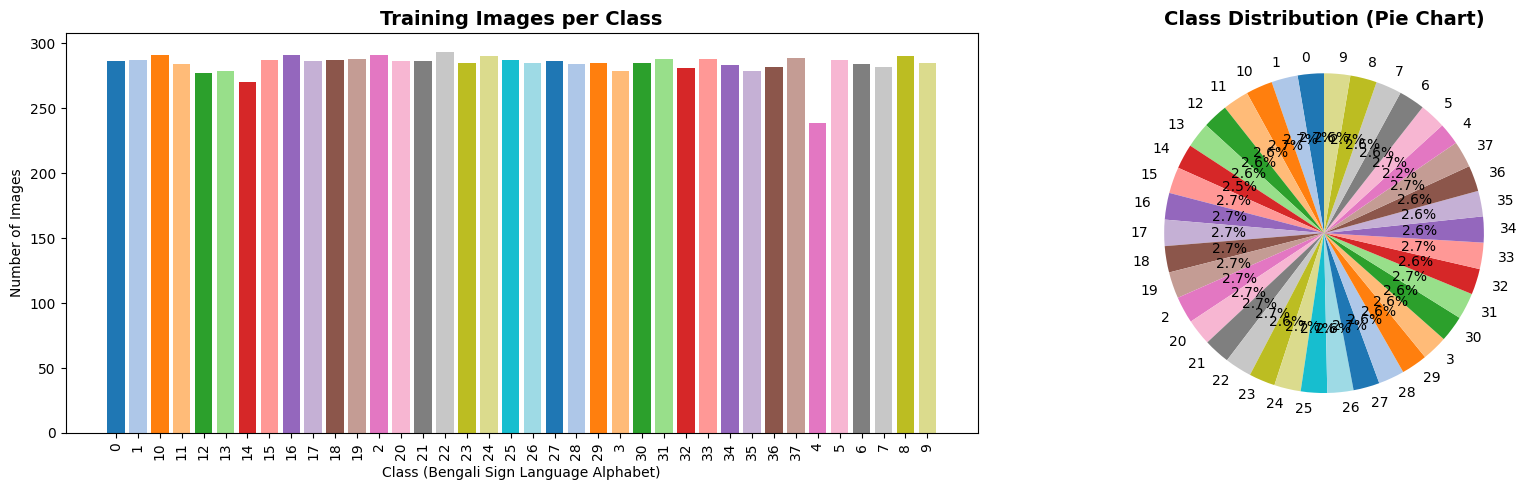

Min images in a class: 239 | Max: 293
Average images per class: 284.0
Dataset is IMBALANCED


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

classes  = list(class_counts.keys())
counts   = list(class_counts.values())

# Bar chart
axes[0].bar(classes, counts, color=plt.cm.tab20.colors * 2)
axes[0].set_title('Training Images per Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (Bengali Sign Language Alphabet)')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=90)

# Pie chart (grouped)
axes[1].pie(counts, labels=classes, autopct='%1.1f%%',
            colors=plt.cm.tab20.colors * 2, startangle=90)
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Min images in a class: {min(counts)} | Max: {max(counts)}')
print(f'Average images per class: {np.mean(counts):.1f}')
print(f'Dataset is {"BALANCED" if (max(counts)-min(counts)) < 50 else "IMBALANCED"}')

### 1.3 Sample Images per Class

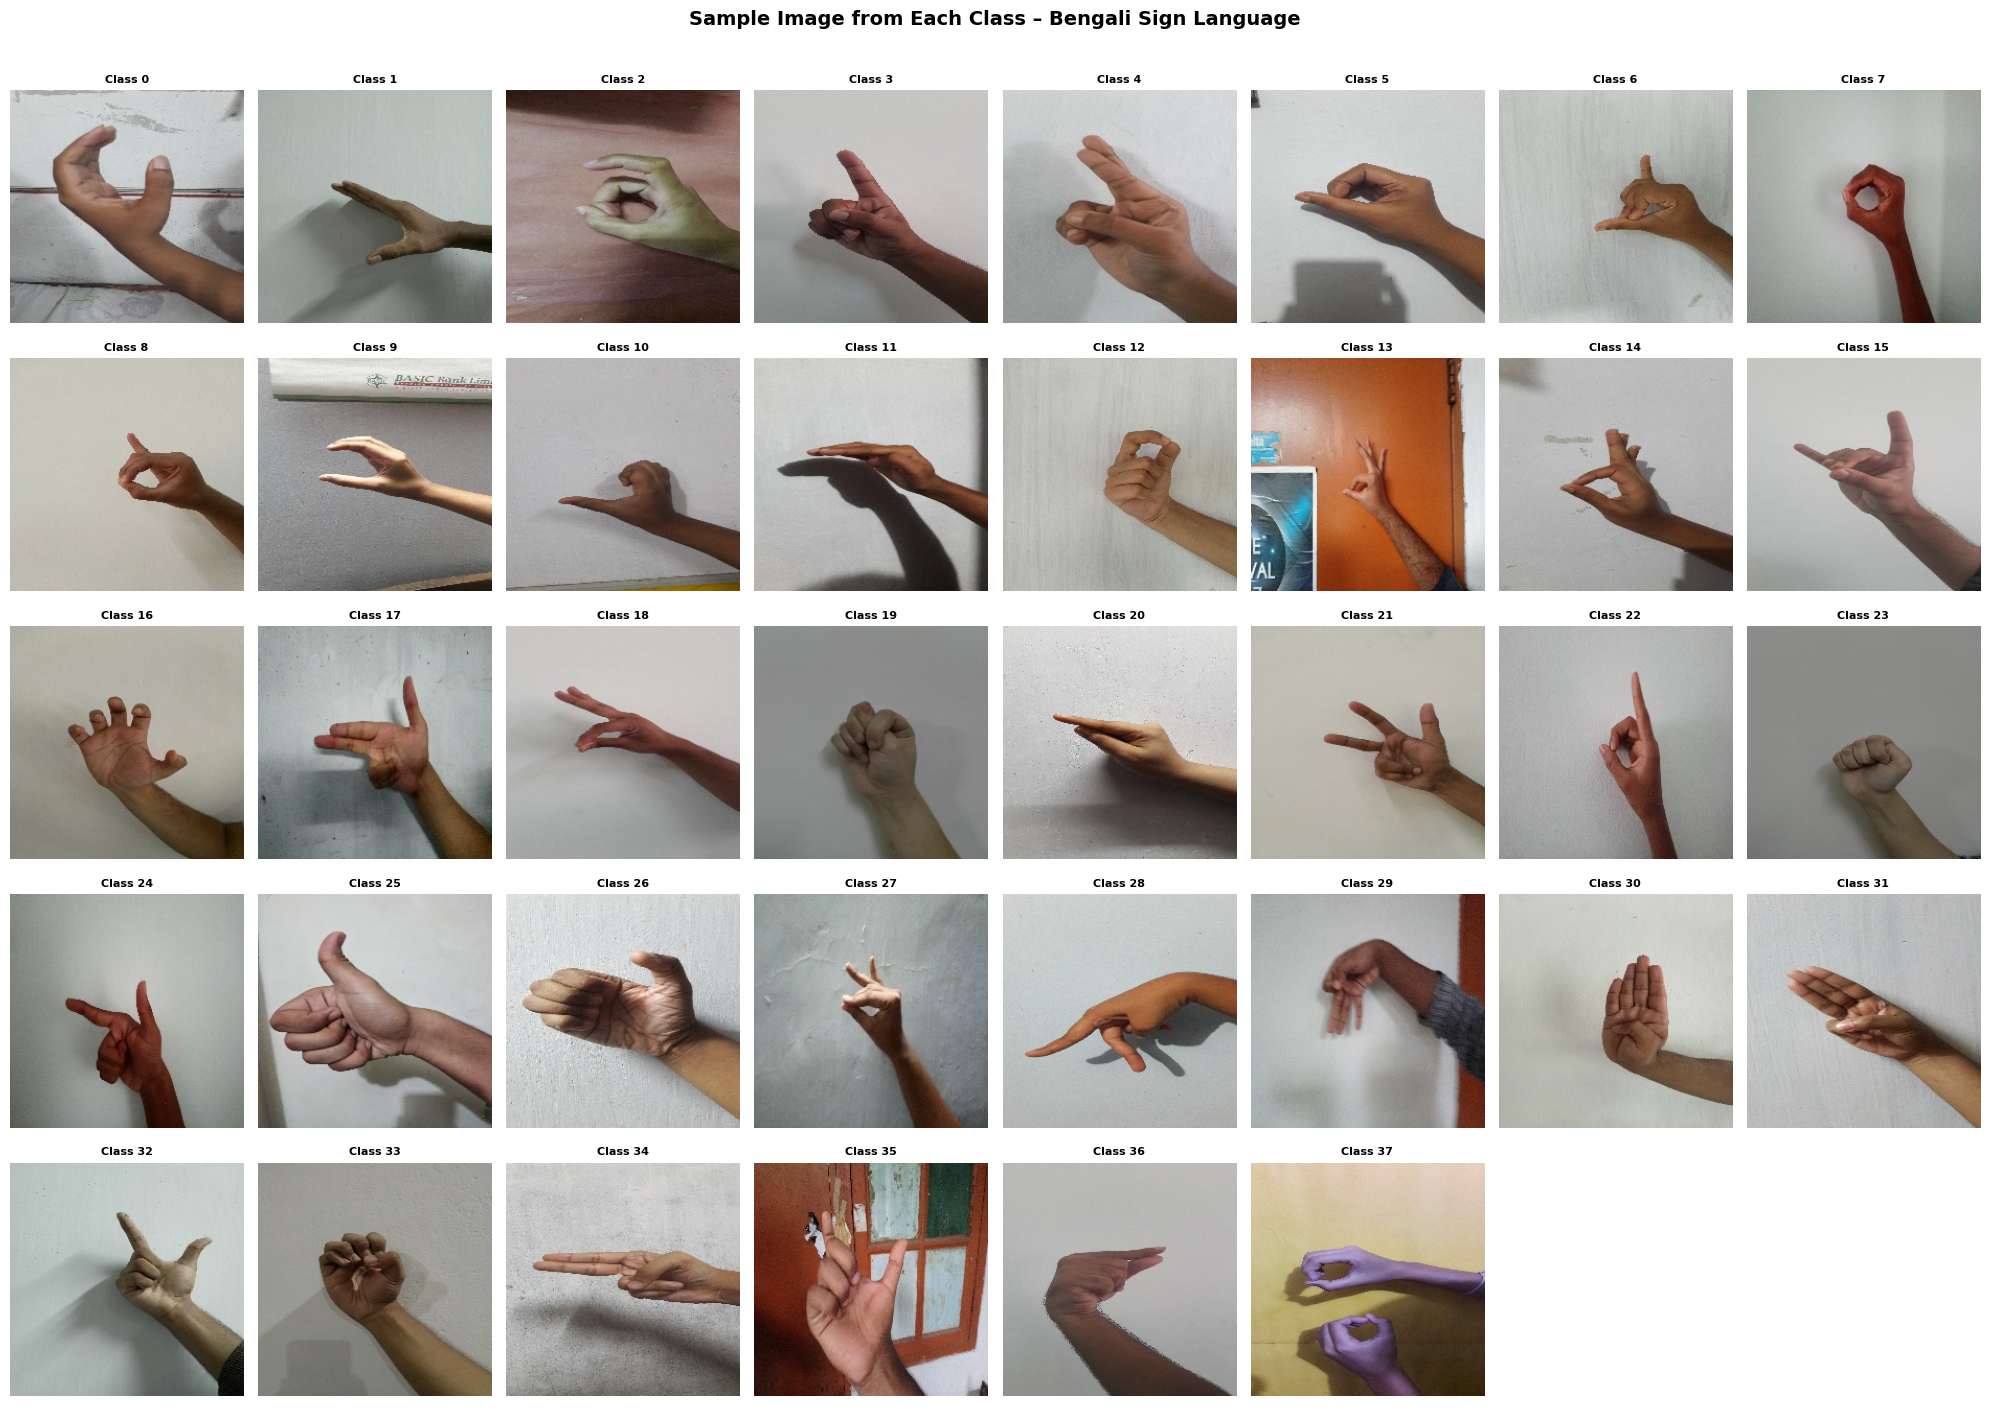

In [ ]:
fig, axes = plt.subplots(5, 8, figsize=(20, 14))
axes = axes.flatten()

for idx, cls in enumerate(sorted(class_counts.keys(), key=lambda x: int(x))):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img      = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(f'Class {cls}', fontsize=8, fontweight='bold')
    axes[idx].axis('off')

# Hide any empty subplot
for idx in range(len(class_counts), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Class – Bengali Sign Language', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Data Preprocessing & Augmentation

In [ ]:
# =====================================================================
# Training Data Generator – WITH Augmentation
# Augmentation helps the model generalize and prevents overfitting
# =====================================================================
train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,        # Normalize pixel values to [0, 1]
    rotation_range    = 15,               # Randomly rotate images ±15°
    width_shift_range = 0.1,              # Horizontal shift
    height_shift_range= 0.1,             # Vertical shift
    zoom_range        = 0.1,             # Zoom in/out
    horizontal_flip   = False,           # Sign language is direction-sensitive
    validation_split  = 0.2              # 80% train / 20% validation
)

# Validation Generator – NO augmentation, only rescale
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = 0.2
)

# Test Generator – NO augmentation
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Flow generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size    = (IMG_HEIGHT, IMG_WIDTH),
    batch_size     = BATCH_SIZE,
    class_mode     = 'categorical',
    subset         = 'training',
    seed           = RANDOM_SEED,
    shuffle        = True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size    = (IMG_HEIGHT, IMG_WIDTH),
    batch_size     = BATCH_SIZE,
    class_mode     = 'categorical',
    subset         = 'validation',
    seed           = RANDOM_SEED,
    shuffle        = False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size    = (IMG_HEIGHT, IMG_WIDTH),
    batch_size     = BATCH_SIZE,
    class_mode     = 'categorical',
    shuffle        = False
)

print(f'Training samples   : {train_generator.samples}')
print(f'Validation samples : {val_generator.samples}')
print(f'Test samples       : {test_generator.samples}')

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Found 0 images belonging to 0 classes.
Training samples   : 8648
Validation samples : 2144
Test samples       : 0


### 1.5 Visualize Augmented Images

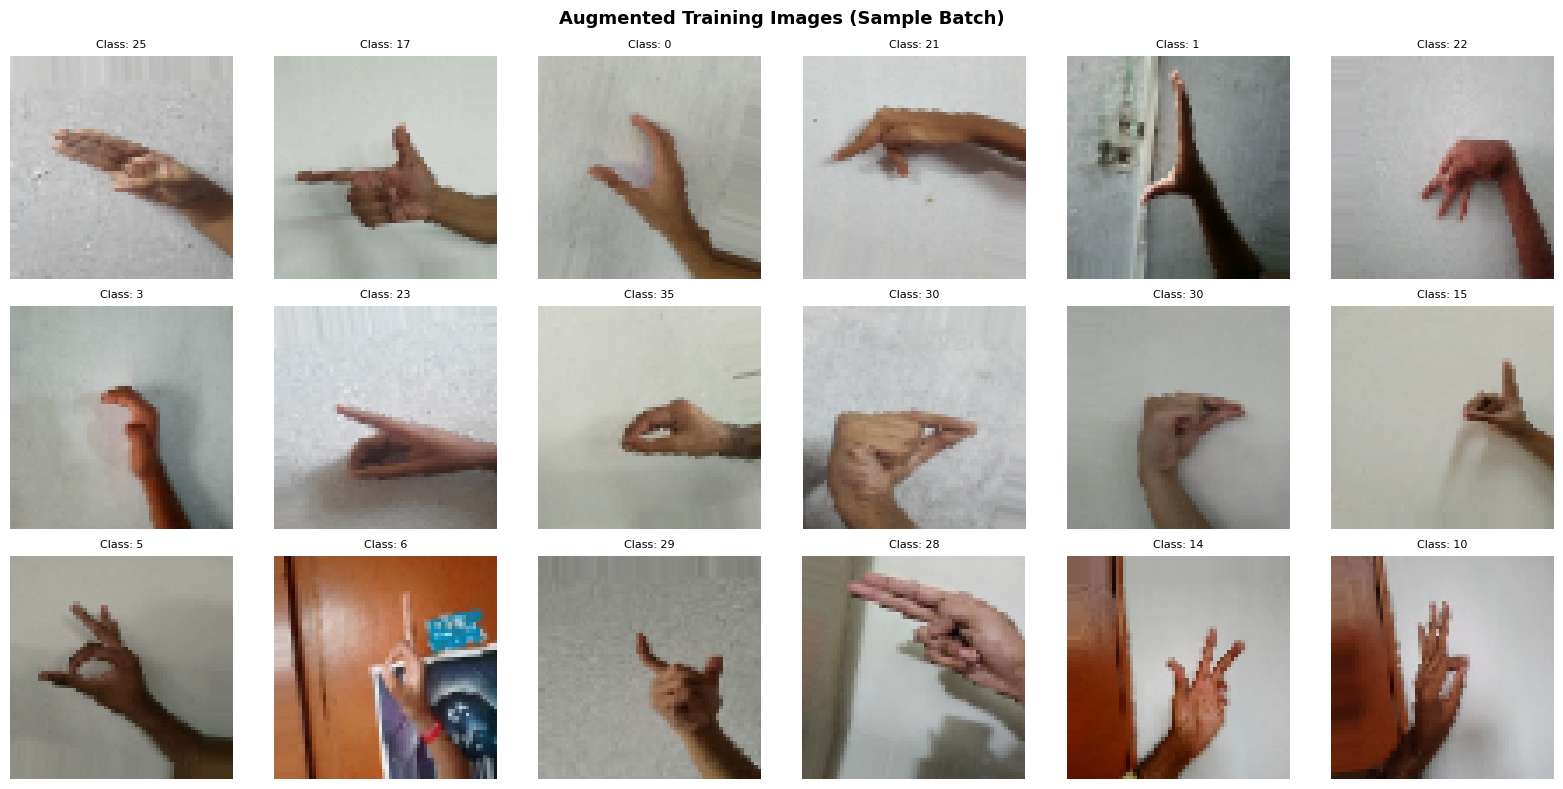

Preprocessing Applied:
  - Pixel Normalization  : [0, 255] → [0.0, 1.0]
  - Rotation             : ±15 degrees
  - Width/Height Shift   : ±10%
  - Zoom                 : ±10%
  - Horizontal Flip      : Disabled (sign language is asymmetric)
  - Train/Val Split      : 80% / 20%


In [ ]:
# Display a batch of augmented training images
images, labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

for i in range(18):
    axes[i].imshow(images[i])
    label_idx = np.argmax(labels[i])
    axes[i].set_title(f'Class: {label_idx}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Augmented Training Images (Sample Batch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print('Preprocessing Applied:')
print('  - Pixel Normalization  : [0, 255] → [0.0, 1.0]')
print('  - Rotation             : ±15 degrees')
print('  - Width/Height Shift   : ±10%')
print('  - Zoom                 : ±10%')
print('  - Horizontal Flip      : Disabled (sign language is asymmetric)')
print('  - Train/Val Split      : 80% / 20%')


## Section 2 (Part A): Baseline CNN Model from Scratch

### 2.1 Build Baseline CNN

In [ ]:
def build_baseline_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    """
    Baseline CNN:
    - 3 Convolutional blocks (Conv2D + ReLU + MaxPooling)
    - 3 Fully Connected layers
    - Softmax output for 38-class classification
    """
    model = models.Sequential(name='Baseline_CNN')

    # ── Block 1 ──────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape,
                            name='Conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool1'))

    # ── Block 2 ──────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same', name='Conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool2'))

    # ── Block 3 ──────────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same', name='Conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool3'))

    # ── Flatten ───────────────────────────────────────────
    model.add(layers.Flatten(name='Flatten'))

    # ── FC Layers ─────────────────────────────────────────
    model.add(layers.Dense(512, activation='relu', name='FC1'))
    model.add(layers.Dense(256, activation='relu', name='FC2'))
    model.add(layers.Dense(128, activation='relu', name='FC3'))

    # ── Output Layer ──────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    return model


baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,457,190 (17.00 MB)

 Trainable params: 4,457,190 (17.00 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Architecture Design Rationale

| Layer | Filters | Kernel | Activation | Reason |
|-------|---------|--------|------------|--------|
| Conv1 | 32 | 3×3 | ReLU | Detect low-level edges/shapes in hand sign images |
| Conv2 | 64 | 3×3 | ReLU | Learn mid-level finger and palm patterns |
| Conv3 | 128 | 3×3 | ReLU | Capture complex sign-specific features |
| MaxPool (×3) | — | 2×2 | — | Reduce spatial dimensions, retain dominant features |
| FC1–3 | 512, 256, 128 | — | ReLU | Non-linear classification from feature vector |
| Output | 38 | — | Softmax | Probability over 38 Bengali alphabet classes |

### 2.3 Compile and Train Baseline Model

In [ ]:
# Compile
baseline_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Callbacks
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# Train
print('Training Baseline CNN ...')
start_time_base = time.time()

history_base = baseline_model.fit(
    train_generator,
    epochs            = EPOCHS_BASE,
    validation_data   = val_generator,
    callbacks         = callbacks_base,
    verbose           = 1
)

time_base = time.time() - start_time_base
print(f'\nBaseline Model Training Time: {time_base:.2f} seconds ({time_base/60:.2f} minutes)')

Training Baseline CNN ...
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 56s 370ms/step - accuracy: 0.0304 - loss: 3.6311 - val_accuracy: 0.0625 - val_loss: 3.5087 - learning_rate: 0.0010
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 336ms/step - accuracy: 0.1252 - loss: 3.2003 - val_accuracy: 0.1898 - val_loss: 2.8976 - learning_rate: 0.0010
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 330ms/step - accuracy: 0.3102 - loss: 2.2953 - val_accuracy: 0.3941 - val_loss: 2.0634 - learning_rate: 0.0010
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 329ms/step - accuracy: 0.4765 - loss: 1.6740 - val_accuracy: 0.4888 - val_loss: 1.7416 - learning_rate: 0.0010
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 332ms/step - accuracy: 0.5601 - loss: 1.3720 - val_accuracy: 0.5396 - val_loss: 1.5423 - learning_rate: 0.0010
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 338ms/step - accuracy: 0.6273 - loss: 1.1723 - val_accuracy: 0.5163 - val_loss: 1.6900 - learning_rate: 0.0010
Epoch 7/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 

### 2.4 Plot Baseline Training Curves

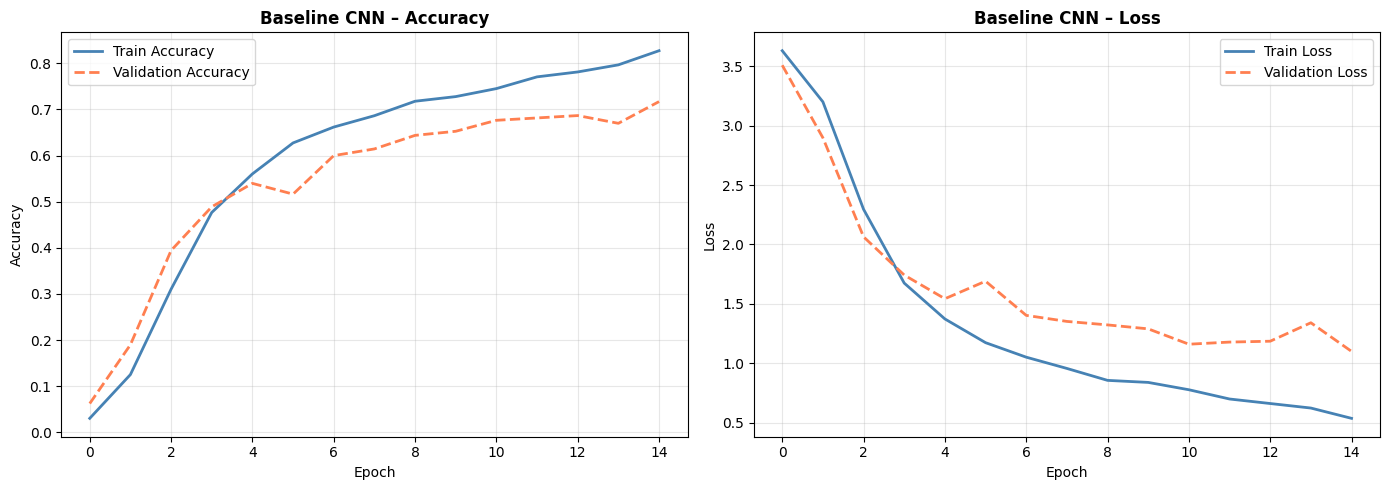

In [ ]:
def plot_history(history, title='Training History', save_name='history.png'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue',  linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral',      linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} – Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue',  linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='coral',      linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} – Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history_base, title='Baseline CNN', save_name='baseline_history.png')

### 2.5 Evaluate Baseline Model

34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 204ms/step

  Baseline CNN – Evaluation Results
  Overall Accuracy: 71.69%

  Classification Report:
              precision    recall  f1-score   support

     Class 0       0.72      0.84      0.77        57
     Class 1       0.76      0.68      0.72        57
     Class 2       0.74      0.83      0.78        58
     Class 3       0.71      0.86      0.77        56
     Class 4       0.78      0.69      0.73        55
     Class 5       0.72      0.76      0.74        55
     Class 6       0.85      0.63      0.72        54
     Class 7       0.95      0.63      0.76        57
     Class 8       0.74      0.84      0.79        58
     Class 9       0.78      0.75      0.77        57
    Class 10       0.59      0.70      0.64        57
    Class 11       0.65      0.42      0.51        57
    Class 12       0.85      0.78      0.81        58
    Class 13       0.83      0.61      0.71        57
    Class 14       0.80      0.79      0.80        57
    

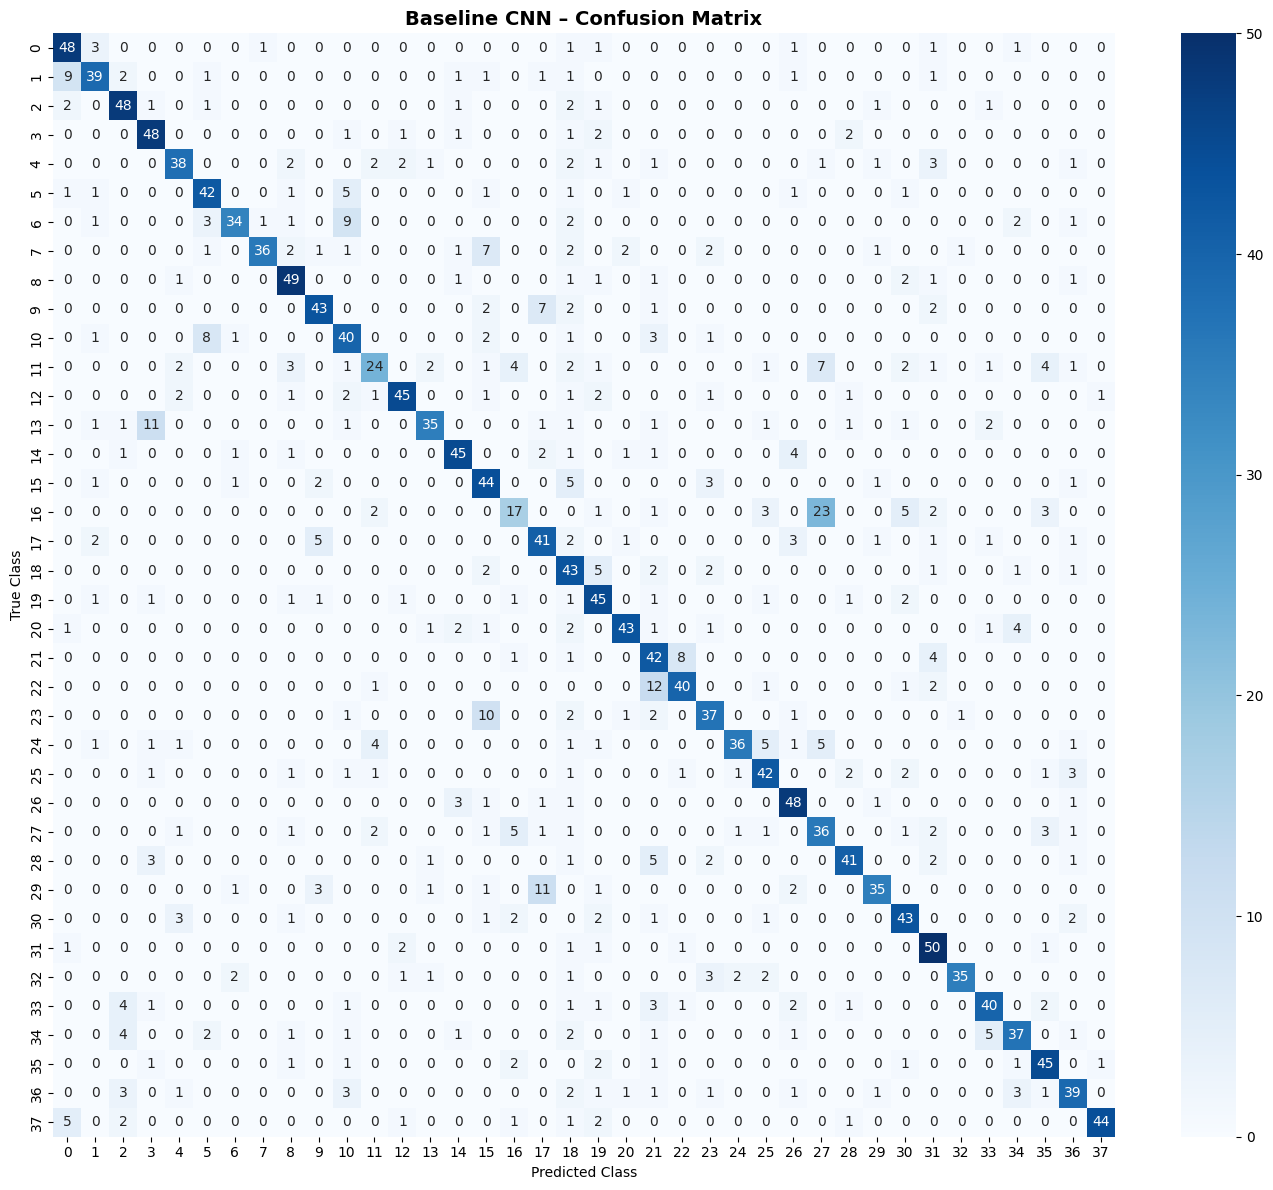

In [ ]:
def evaluate_model(model, generator, model_name='Model'):
    """
    Full evaluation: accuracy, classification report, confusion matrix.
    Returns true labels, predicted labels, and overall accuracy.
    """
    generator.reset()
    y_pred_prob = model.predict(generator, verbose=1)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = generator.classes

    acc = accuracy_score(y_true, y_pred)
    print(f'\n{"="*55}')
    print(f'  {model_name} – Evaluation Results')
    print(f'{"="*55}')
    print(f'  Overall Accuracy: {acc * 100:.2f}%')
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=[f'Class {i}' for i in range(NUM_CLASSES)]))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES))
    plt.title(f'{model_name} – Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return y_true, y_pred, acc


y_true_base, y_pred_base, acc_base = evaluate_model(baseline_model, val_generator, 'Baseline CNN')

### 2.6 Inference on Sample Test Images

Found 3 test images:
  /content/drive/MyDrive/AI FINAL ASSESSMENT/Test/20180625_203333.jpg
  /content/drive/MyDrive/AI FINAL ASSESSMENT/Test/20180625_230047.jpg
  /content/drive/MyDrive/AI FINAL ASSESSMENT/Test/20180701_194331.jpg


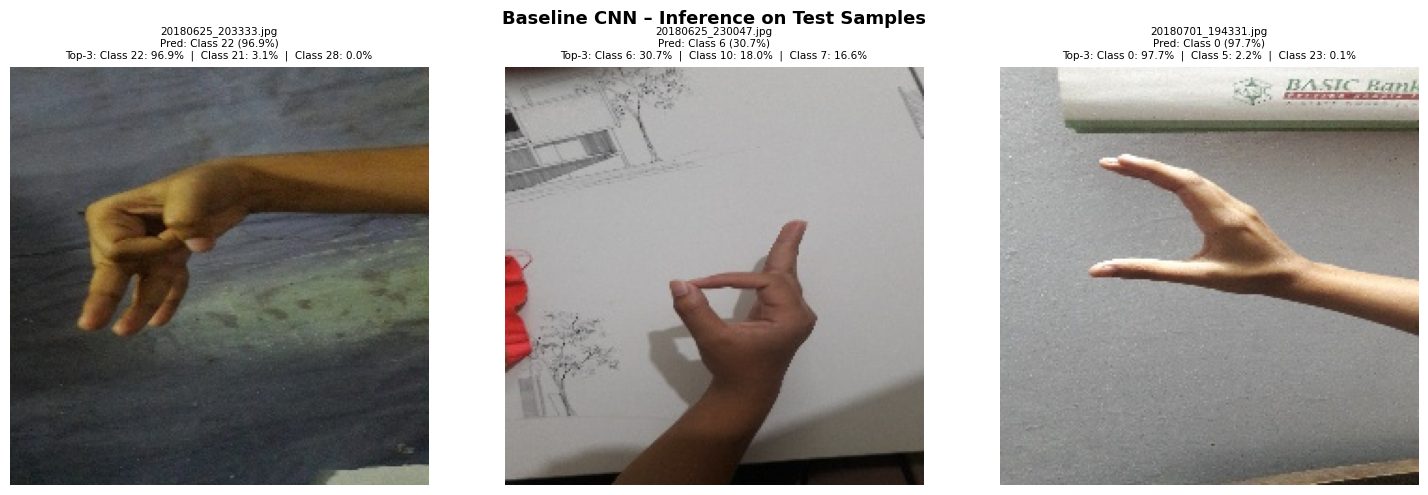

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

VALID_IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def collect_test_images(test_dir, max_images=6):
    collected = []
    for dirpath, _, filenames in os.walk(test_dir):
        for fname in sorted(filenames):
            if os.path.splitext(fname)[1].lower() in VALID_IMG_EXTS:
                collected.append(os.path.join(dirpath, fname))
                if len(collected) >= max_images:
                    return collected
    return collected

def predict_single_image(model, img_path, true_label=None, model_name='Model'):
    img_display = keras_image.load_img(img_path)
    img_input   = keras_image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_arr     = keras_image.img_to_array(img_input) / 255.0
    img_arr     = np.expand_dims(img_arr, axis=0)

    pred_prob  = model.predict(img_arr, verbose=0)
    pred_class = np.argmax(pred_prob)
    confidence = np.max(pred_prob) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    title = f'{model_name}\nPredicted: Class {pred_class} ({confidence:.1f}%)'
    if true_label is not None:
        title += f'\nTrue: Class {true_label}'
    plt.title(title, fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return pred_class, confidence


# ── Collect test images (works for flat folder OR subfolders) ──
test_image_paths = collect_test_images(TEST_DIR, max_images=6)
print(f'Found {len(test_image_paths)} test images:')
for p in test_image_paths:
    print(f'  {p}')

# ── Plot predictions ───────────────────────────────────────────
n      = len(test_image_paths)
n_cols = min(3, n)
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for idx, img_path in enumerate(test_image_paths):
    img_display = keras_image.load_img(img_path)                              # original for display
    img_input   = keras_image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_arr     = keras_image.img_to_array(img_input) / 255.0
    img_arr     = np.expand_dims(img_arr, axis=0)

    pred       = baseline_model.predict(img_arr, verbose=0)
    pred_class = np.argmax(pred)
    confidence = np.max(pred) * 100

    top3_idx = np.argsort(pred[0])[::-1][:3]
    top3_str = '  |  '.join([f'Class {top3_idx[i]}: {pred[0][top3_idx[i]]*100:.1f}%' for i in range(3)])

    axes[idx].imshow(img_display)
    axes[idx].set_title(
        f'{os.path.basename(img_path)}\n'
        f'Pred: Class {pred_class} ({confidence:.1f}%)\n'
        f'Top-3: {top3_str}',
        fontsize=7.5
    )
    axes[idx].axis('off')

# hide unused subplots if less than 6 images
for idx in range(len(test_image_paths), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Baseline CNN – Inference on Test Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_inference.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 3 (Part A): Deeper CNN with Regularization

### 3.1 Build Deeper CNN

In [ ]:
def build_deep_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    """
    Deep CNN with:
    - 6 Convolutional blocks (double baseline)
    - Batch Normalization after each Conv layer
    - Dropout for regularization
    - 3 FC layers with Dropout
    """
    model = models.Sequential(name='Deep_CNN')

    # ── Block 1 ──────────────────────────────────────────
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape, name='Conv1a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same', name='Conv1b'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2 ──────────────────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same', name='Conv2a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same', name='Conv2b'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Block 3 ──────────────────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same', name='Conv3a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', name='Conv3b'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Flatten ───────────────────────────────────────────
    model.add(layers.Flatten())

    # ── FC Layers ─────────────────────────────────────────
    model.add(layers.Dense(1024, activation='relu', name='FC1'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(512, activation='relu', name='FC2'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(256, activation='relu', name='FC3'))
    model.add(layers.Dropout(0.3))

    # ── Output ────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    return model


deep_model = build_deep_cnn()
deep_model.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1a (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1b (Conv2D)                 │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2a (Conv2D)                 │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2b (Conv2D)                 │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3a (Conv2D)                 │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3b (Conv2D)                 │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             

 Total params: 9,350,470 (35.67 MB)

 Trainable params: 9,346,502 (35.65 MB)

 Non-trainable params: 3,968 (15.50 KB)

### 3.2 Regularization Techniques Used

| Technique | Where Applied | Purpose |
|-----------|---------------|---------|
| **Batch Normalization** | After every Conv layer | Stabilizes training, speeds convergence, reduces internal covariate shift |
| **Dropout (0.25)** | After each pooling block | Randomly deactivates 25% of neurons, prevents co-adaptation |
| **Dropout (0.5)** | After FC1 | Strongest dropout at the widest bottleneck to prevent overfitting |
| **Early Stopping** | On val_loss | Stops training when model stops improving |
| **ReduceLROnPlateau** | On val_loss | Reduces learning rate when plateau is detected |

### 3.3 Train Deep CNN with Adam Optimizer

In [ ]:
deep_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_deep_model.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print('Training Deep CNN (Adam) ...')
start_time_deep_adam = time.time()

history_deep_adam = deep_model.fit(
    train_generator,
    epochs          = EPOCHS_DEEP,
    validation_data = val_generator,
    callbacks       = callbacks_deep,
    verbose         = 1
)

time_deep_adam = time.time() - start_time_deep_adam
print(f'\nDeep CNN (Adam) Training Time: {time_deep_adam:.2f}s ({time_deep_adam/60:.2f} min)')

Training Deep CNN (Adam) ...
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.0502 - loss: 4.3385

136/136 ━━━━━━━━━━━━━━━━━━━━ 76s 437ms/step - accuracy: 0.0671 - loss: 4.0484 - val_accuracy: 0.0261 - val_loss: 4.2566 - learning_rate: 0.0010
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.1035 - loss: 3.5416

136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 341ms/step - accuracy: 0.1216 - loss: 3.3973 - val_accuracy: 0.0294 - val_loss: 4.0582 - learning_rate: 0.0010
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.2055 - loss: 2.8648

136/136 ━━━━━━━━━━━━━━━━━━━━ 48s 349ms/step - accuracy: 0.2397 - loss: 2.6833 - val_accuracy: 0.1483 - val_loss: 3.5049 - learning_rate: 0.0010
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.3380 - loss: 2.1904

136/136 ━━━━━━━━━━━━━━━━━━━━ 48s 351ms/step - accuracy: 0.3586 - loss: 2.1128 - val_accuracy: 0.3517 - val_loss: 2.2862 - learning_rate: 0.0010
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.4294 - loss: 1.8607

...

136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 368ms/step - accuracy: 0.5654 - loss: 1.3874 - val_accuracy: 0.5788 - val_loss: 1.4963 - learning_rate: 0.0010
Epoch 8/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.6043 - loss: 1.2489

136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 340ms/step - accuracy: 0.6094 - loss: 1.2282 - val_accuracy: 0.5951 - val_loss: 1.4174 - learning_rate: 0.0010
Epoch 9/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 339ms/step - accuracy: 0.6428 - loss: 1.1278 - val_accuracy: 0.4697 - val_loss: 1.8985 - learning_rate: 0.0010
Epoch 10/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 344ms/step - accuracy: 0.6710 - loss: 1.0205 - val_accuracy: 0.5037 - val_loss: 1.6811 - learning_rate: 0.0010
Epoch 11/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6800 - loss: 1.0196
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 346ms/step - accuracy: 0.6876 - loss: 0.9839 - val_accuracy: 0.6087 - val_loss: 1.4958 - learning_rate: 0.0010
Epoch 12/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7332 - loss: 0.8333

136/136 ━━━━━━━━━━━━━━━━━━━━ 48s 350ms/step - accuracy: 0.7382 - loss: 0.8368 - val_accuracy: 0.7174 - val_loss: 0.9865 - learning_rate: 5.0000e-04
Epoch 13/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 80s 342ms/step - accuracy: 0.7477 - loss: 0.7972 - val_accuracy: 0.4851 - val_loss: 1.9677 - learning_rate: 5.0000e-04
Epoch 14/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7562 - loss: 0.7799

136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 344ms/step - accuracy: 0.7502 - loss: 0.7875 - val_accuracy: 0.7458 - val_loss: 0.9995 - learning_rate: 5.0000e-04
Epoch 15/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.7581 - loss: 0.7338
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 343ms/step - accuracy: 0.7602 - loss: 0.7404 - val_accuracy: 0.6203 - val_loss: 1.2852 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 12.

Deep CNN (Adam) Training Time: 772.97s (12.88 min)


### 3.4 Train Deep CNN with SGD Optimizer (Optimizer Comparison)

In [ ]:
# Rebuild the same architecture for fair comparison
deep_model_sgd = build_deep_cnn()

deep_model_sgd.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('Training Deep CNN (SGD + Momentum + Nesterov) ...')
start_time_deep_sgd = time.time()

history_deep_sgd = deep_model_sgd.fit(
    train_generator,
    epochs          = EPOCHS_DEEP,
    validation_data = val_generator,
    callbacks       = callbacks_sgd,
    verbose         = 1
)

time_deep_sgd = time.time() - start_time_deep_sgd
print(f'\nDeep CNN (SGD) Training Time: {time_deep_sgd:.2f}s ({time_deep_sgd/60:.2f} min)')

Training Deep CNN (SGD + Momentum + Nesterov) ...
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 65s 400ms/step - accuracy: 0.0608 - loss: 4.0348 - val_accuracy: 0.0257 - val_loss: 3.9324 - learning_rate: 0.0100
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 340ms/step - accuracy: 0.1094 - loss: 3.4433 - val_accuracy: 0.0266 - val_loss: 4.6450 - learning_rate: 0.0100
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 333ms/step - accuracy: 0.1820 - loss: 2.9594 - val_accuracy: 0.0308 - val_loss: 5.1646 - learning_rate: 0.0100
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 336ms/step - accuracy: 0.2908 - loss: 2.3885 - val_accuracy: 0.2253 - val_loss: 2.9424 - learning_rate: 0.0100
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 342ms/step - accuracy: 0.3719 - loss: 2.0524 - val_accuracy: 0.1586 - val_loss: 3.6025 - learning_rate: 0.0100
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 45s 333ms/step - accuracy: 0.4391 - loss: 1.8002 - val_accuracy: 0.4431 - val_loss: 1.9403 - learning_rate: 0.0100
Epoch 7/15
136/136 ━

### 3.5 Evaluate Deep CNN Models

34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step

  Deep CNN (Adam) – Evaluation Results
  Overall Accuracy: 71.74%

  Classification Report:
              precision    recall  f1-score   support

     Class 0       0.84      0.81      0.82        57
     Class 1       0.88      0.86      0.87        57
     Class 2       0.84      0.81      0.82        58
     Class 3       0.63      0.82      0.71        56
     Class 4       0.82      0.76      0.79        55
     Class 5       0.42      0.91      0.57        55
     Class 6       0.88      0.41      0.56        54
     Class 7       0.68      0.63      0.65        57
     Class 8       0.76      0.90      0.83        58
     Class 9       0.94      0.86      0.90        57
    Class 10       0.40      0.51      0.45        57
    Class 11       0.93      0.46      0.61        57
    Class 12       0.63      0.81      0.71        58
    Class 13       0.93      0.46      0.61        57
    Class 14       0.85      0.89      0.87        57
 

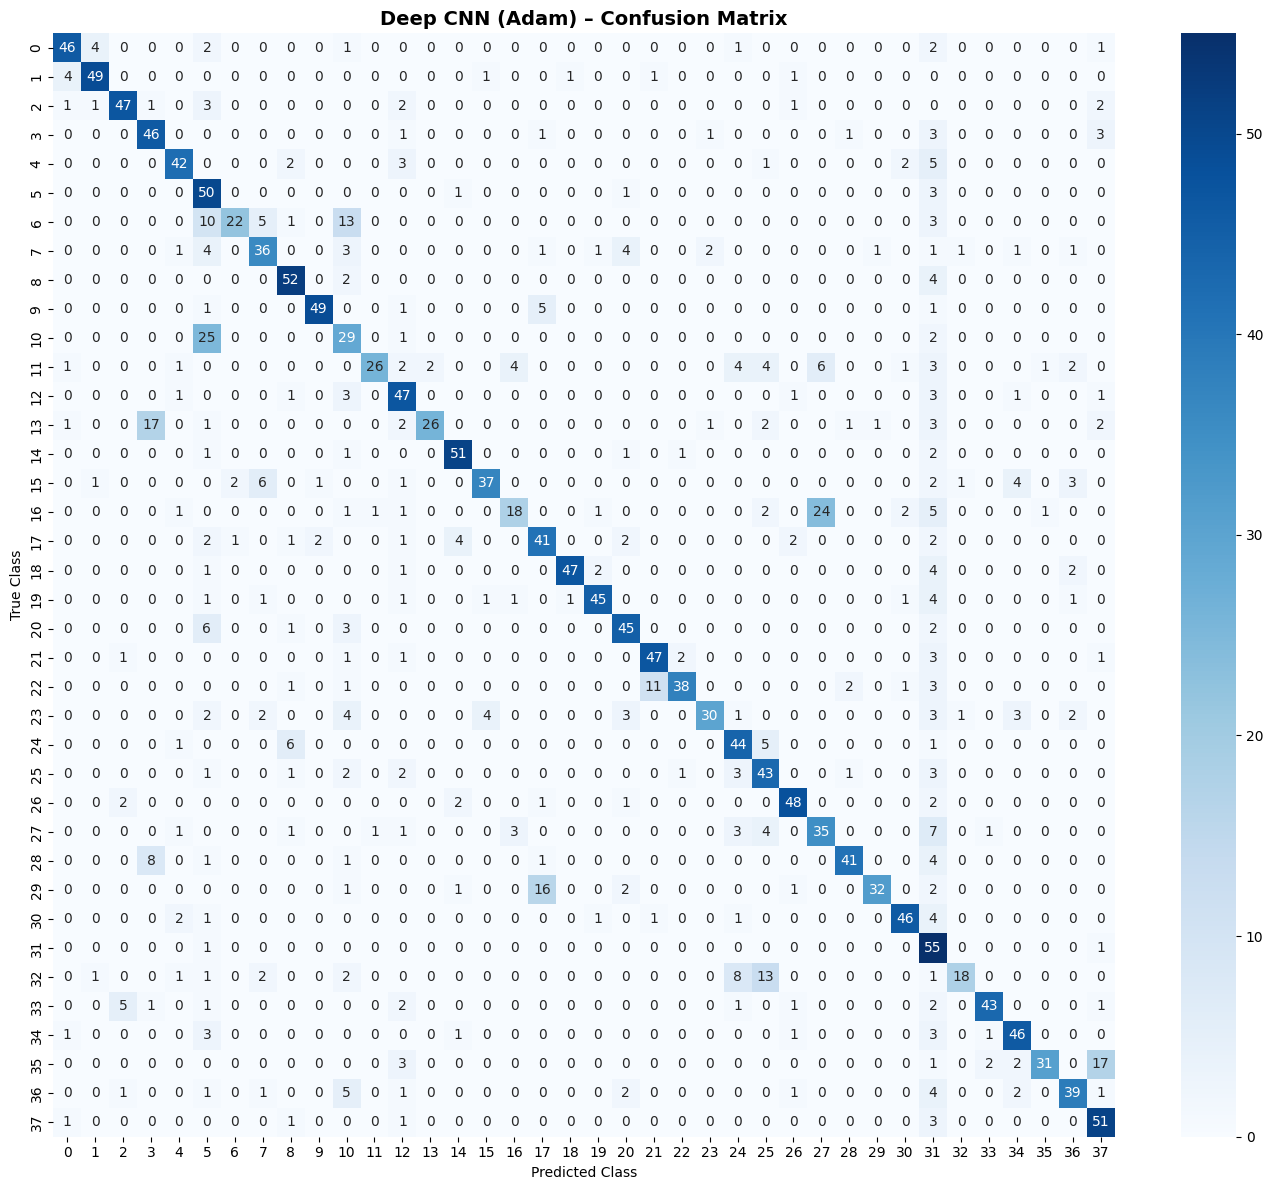

34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step

  Deep CNN (SGD) – Evaluation Results
  Overall Accuracy: 70.71%

  Classification Report:
              precision    recall  f1-score   support

     Class 0       0.72      0.81      0.76        57
     Class 1       0.90      0.79      0.84        57
     Class 2       0.88      0.76      0.81        58
     Class 3       0.78      0.82      0.80        56
     Class 4       0.92      0.65      0.77        55
     Class 5       1.00      0.22      0.36        55
     Class 6       0.94      0.59      0.73        54
     Class 7       0.92      0.40      0.56        57
     Class 8       0.91      0.84      0.88        58
     Class 9       0.78      0.89      0.84        57
    Class 10       0.43      0.72      0.54        57
    Class 11       0.89      0.30      0.45        57
    Class 12       0.82      0.86      0.84        58
    Class 13       0.89      0.68      0.77        57
    Class 14       0.87      0.82      0.85        57
  

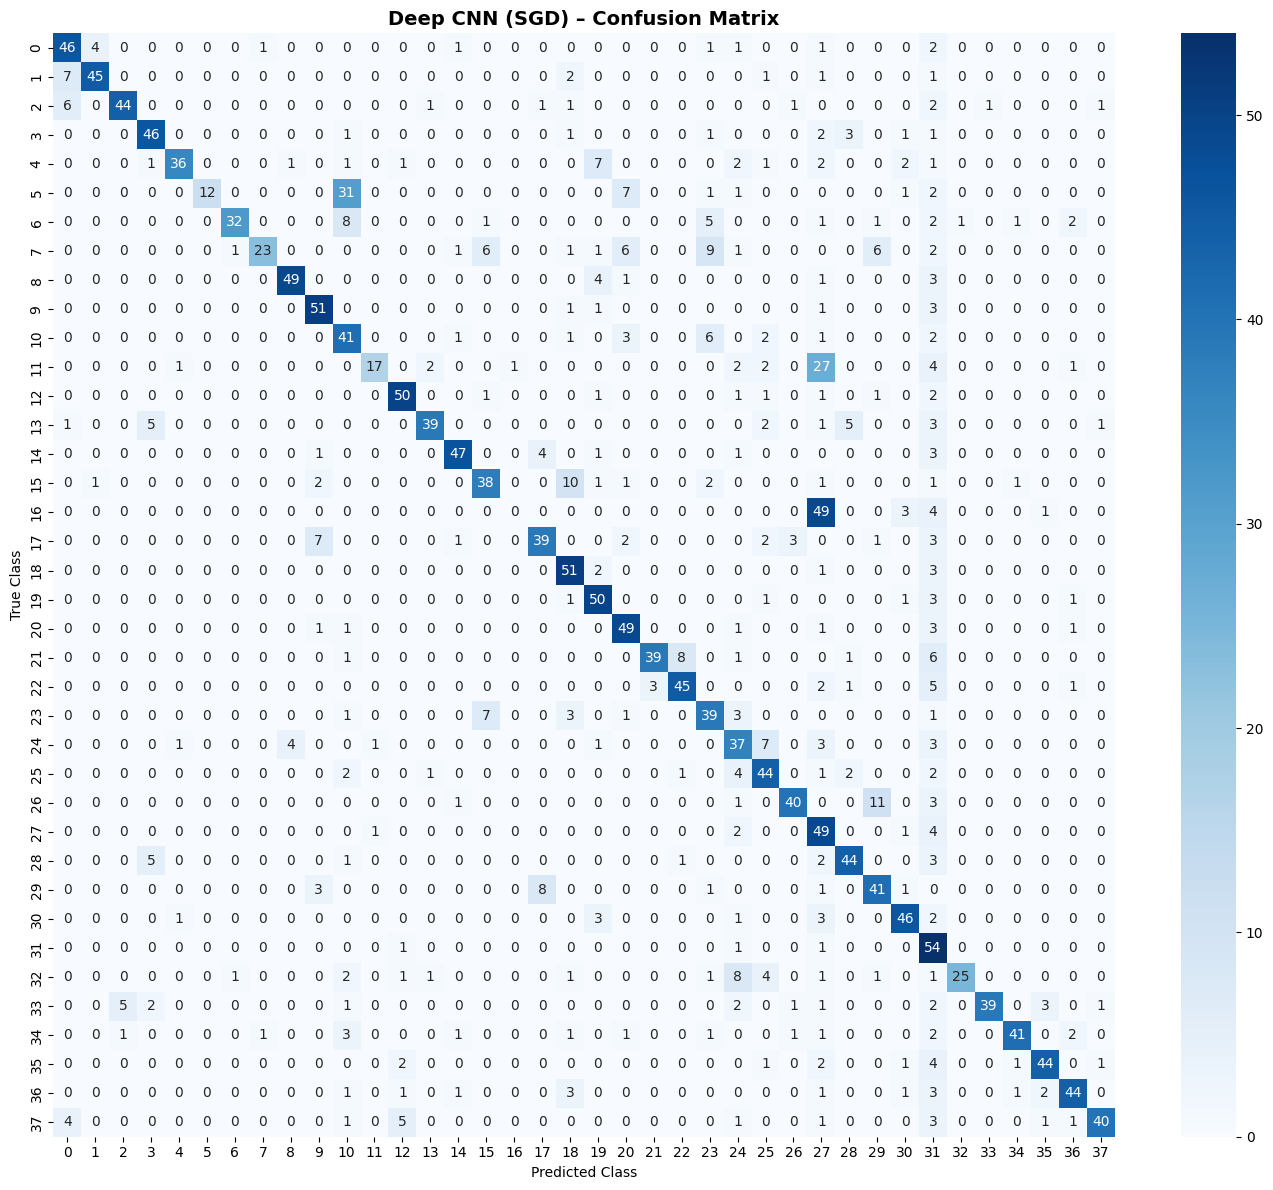

In [ ]:
y_true_deep_adam, y_pred_deep_adam, acc_deep_adam = evaluate_model(
    deep_model, val_generator, 'Deep CNN (Adam)')

y_true_deep_sgd, y_pred_deep_sgd, acc_deep_sgd = evaluate_model(
    deep_model_sgd, val_generator, 'Deep CNN (SGD)')


## Section 4 (Part A): Experimentation & Comparative Analysis

### 4.1 Accuracy and Loss Comparison

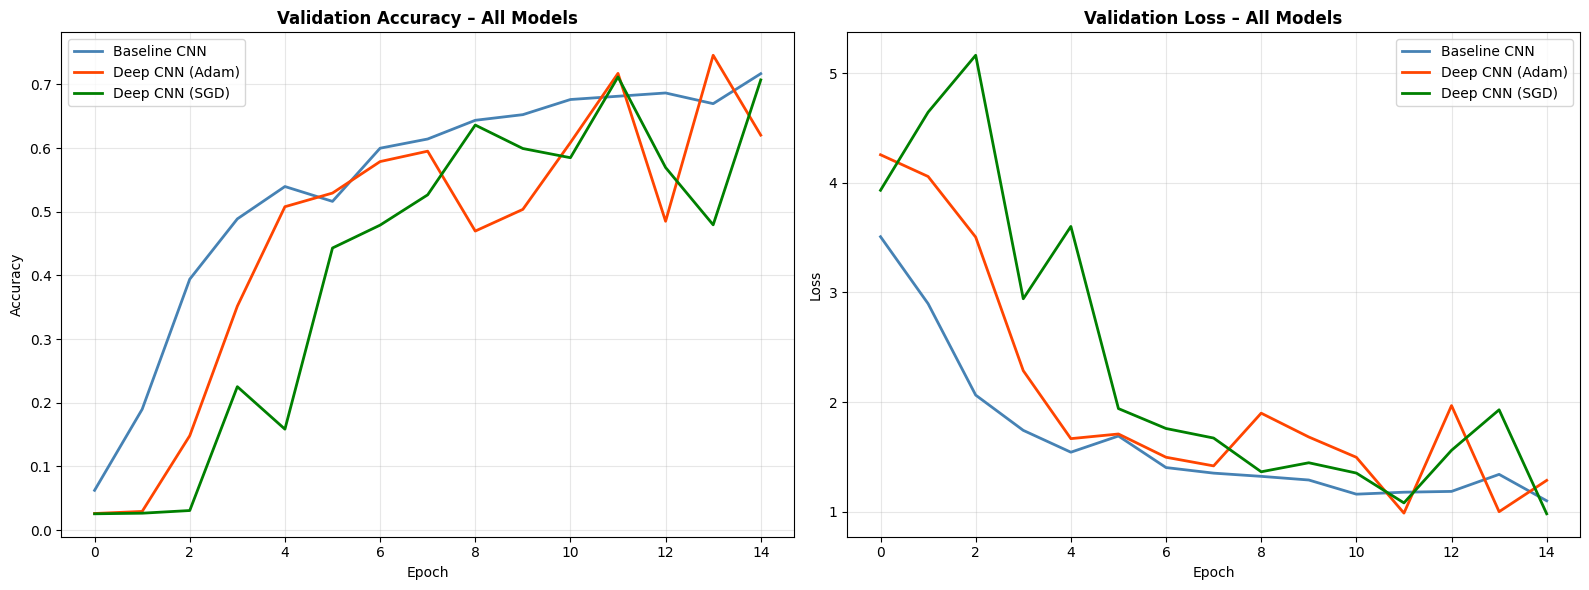

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].plot(history_base.history['val_accuracy'],      label='Baseline CNN',    color='steelblue',  linewidth=2)
axes[0].plot(history_deep_adam.history['val_accuracy'], label='Deep CNN (Adam)', color='orangered',  linewidth=2)
axes[0].plot(history_deep_sgd.history['val_accuracy'],  label='Deep CNN (SGD)',  color='green',      linewidth=2)
axes[0].set_title('Validation Accuracy – All Models', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(history_base.history['val_loss'],      label='Baseline CNN',    color='steelblue',  linewidth=2)
axes[1].plot(history_deep_adam.history['val_loss'], label='Deep CNN (Adam)', color='orangered',  linewidth=2)
axes[1].plot(history_deep_sgd.history['val_loss'],  label='Deep CNN (SGD)',  color='green',      linewidth=2)
axes[1].set_title('Validation Loss – All Models', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Summary Comparison Table

In [ ]:
print('\n' + '='*65)
print(f'{"Model":<25} {"Val Accuracy":>13} {"Train Time (s)":>15}')
print('='*65)
print(f'{"Baseline CNN":<25} {acc_base*100:>12.2f}% {time_base:>15.1f}s')
print(f'{"Deep CNN (Adam)":<25} {acc_deep_adam*100:>12.2f}% {time_deep_adam:>15.1f}s')
print(f'{"Deep CNN (SGD)":<25} {acc_deep_sgd*100:>12.2f}% {time_deep_sgd:>15.1f}s')
print('='*65)

print('\nKey Observations:')
print(f'  - Deep CNN (Adam) vs Baseline accuracy gain : {(acc_deep_adam - acc_base)*100:.2f}%')
print(f'  - Deep CNN (SGD)  vs Baseline accuracy gain : {(acc_deep_sgd  - acc_base)*100:.2f}%')
print(f'  - Adam vs SGD accuracy difference           : {(acc_deep_adam - acc_deep_sgd)*100:.2f}%')
print(f'  - Deep CNN (Adam) training cost vs Baseline : {time_deep_adam/time_base:.1f}x')


Model                      Val Accuracy  Train Time (s)
Baseline CNN                     71.69%           695.2s
Deep CNN (Adam)                  71.74%           773.0s
Deep CNN (SGD)                   70.71%           713.8s

Key Observations:
  - Deep CNN (Adam) vs Baseline accuracy gain : 0.05%
  - Deep CNN (SGD)  vs Baseline accuracy gain : -0.98%
  - Adam vs SGD accuracy difference           : 1.03%
  - Deep CNN (Adam) training cost vs Baseline : 1.1x


### 4.3 Ablation Study – Remove Dropout

Training Ablation Model (No Dropout) ...
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 64s 387ms/step - accuracy: 0.2522 - loss: 2.7286 - val_accuracy: 0.0266 - val_loss: 10.6426
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 338ms/step - accuracy: 0.5522 - loss: 1.4448 - val_accuracy: 0.0984 - val_loss: 4.1076
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 342ms/step - accuracy: 0.6759 - loss: 1.0475 - val_accuracy: 0.2887 - val_loss: 2.7776
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 47s 344ms/step - accuracy: 0.7180 - loss: 0.8946 - val_accuracy: 0.4991 - val_loss: 1.8204
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 336ms/step - accuracy: 0.7554 - loss: 0.7629 - val_accuracy: 0.6325 - val_loss: 1.2789
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 338ms/step - accuracy: 0.7961 - loss: 0.6445 - val_accuracy: 0.6119 - val_loss: 1.5155
Epoch 7/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 339ms/step - accuracy: 0.8061 - loss: 0.6012 - val_accuracy: 0.6810 - val_loss: 1.1295
Epoch 8/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 4

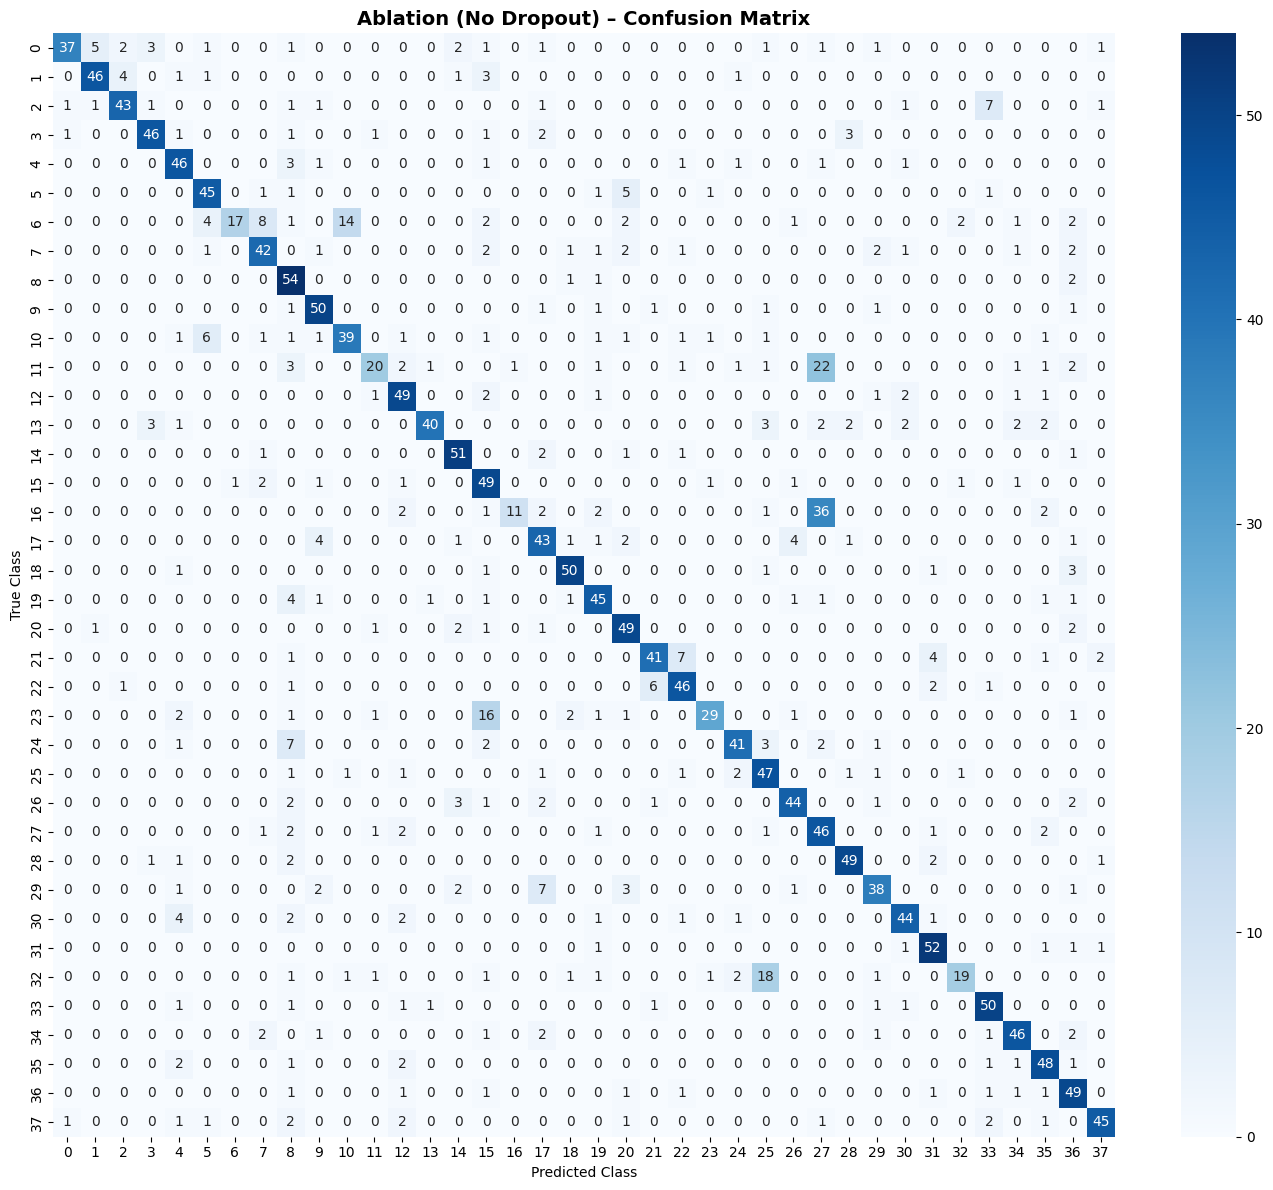


Ablation Study Result:
  Deep CNN with Dropout    : 71.74%
  Deep CNN without Dropout : 74.91%
  Impact of Dropout        : -3.17% difference


In [ ]:
def build_deep_cnn_no_dropout(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    """Deep CNN without Dropout – for ablation study."""
    model = models.Sequential(name='Deep_CNN_No_Dropout')

    for filters in [32, 64, 128]:
        model.add(layers.Conv2D(filters, (3,3), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Conv2D(filters, (3,3), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.MaxPooling2D((2,2)))
        # NO DROPOUT HERE

    model.add(layers.Flatten())
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


ablation_model = build_deep_cnn_no_dropout()
ablation_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('Training Ablation Model (No Dropout) ...')
history_ablation = ablation_model.fit(
    train_generator,
    epochs          = EPOCHS_DEEP,
    validation_data = val_generator,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose         = 1
)

_, _, acc_ablation = evaluate_model(ablation_model, val_generator, 'Ablation (No Dropout)')

print(f'\nAblation Study Result:')
print(f'  Deep CNN with Dropout    : {acc_deep_adam*100:.2f}%')
print(f'  Deep CNN without Dropout : {acc_ablation*100:.2f}%')
print(f'  Impact of Dropout        : {(acc_deep_adam - acc_ablation)*100:.2f}% difference')

### 4.4 Ablation Study – Compare Histories

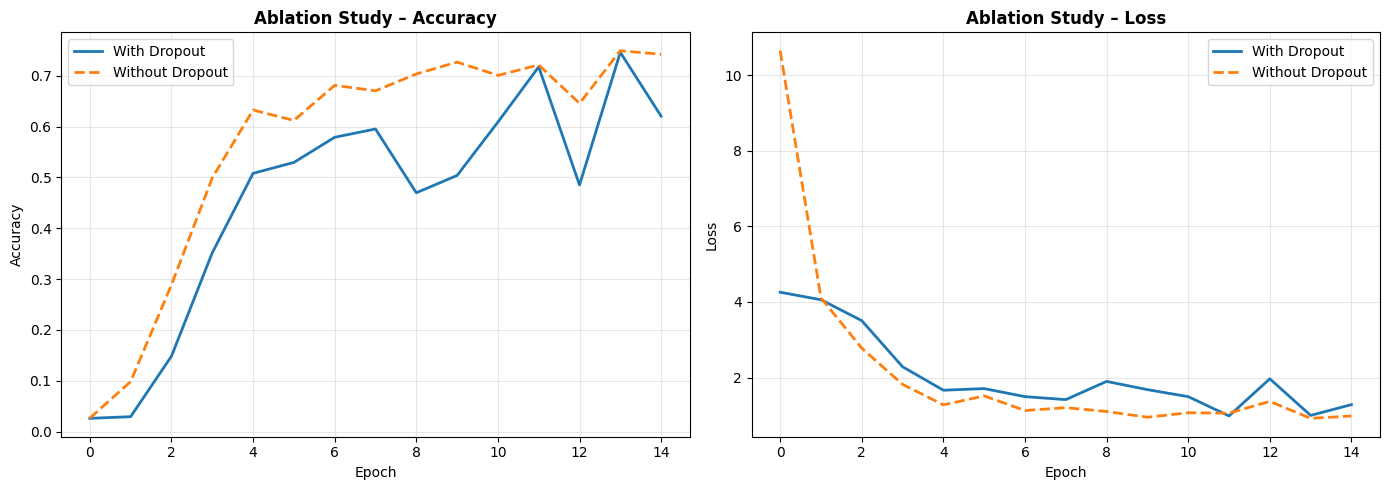

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(axes, ['val_accuracy', 'val_loss'], ['Accuracy', 'Loss']):
    ax.plot(history_deep_adam.history[metric], label='With Dropout',    linewidth=2)
    ax.plot(history_ablation.history[metric],  label='Without Dropout', linewidth=2, linestyle='--')
    ax.set_title(f'Ablation Study – {ylabel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5 (Part B): Transfer Learning – Fine-Tuning MobileNetV2

### 5.1 Why MobileNetV2?

MobileNetV2 is chosen for this task because:
- It is computationally efficient and fast — ideal for a 38-class sign language task
- Pre-trained on ImageNet (1.4M+ images), it has rich learned feature representations
- It handles 224×224 input well, matching our resized images
- Performs comparably to VGG16/ResNet50 with far fewer parameters

### 5.2 Data Generators for Transfer Learning (224×224)

In [ ]:
TL_IMG_SIZE = 128  # Set to 128 to match scratch CNN and reduce laptop load

tl_train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,
    rotation_range    = 15,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    zoom_range        = 0.1,
    validation_split  = 0.2
)

tl_val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = 0.2
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (TL_IMG_SIZE, TL_IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = RANDOM_SEED
)

tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (TL_IMG_SIZE, TL_IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = RANDOM_SEED,
    shuffle      = False
)

print(f'TL Train: {tl_train_gen.samples} | TL Val: {tl_val_gen.samples}')

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
TL Train: 8648 | TL Val: 2144


### 5.3 Phase 1 – Feature Extraction (Frozen Base)

In [ ]:
# Load MobileNetV2 without the top classification head
base_model = MobileNetV2(
    input_shape = (TL_IMG_SIZE, TL_IMG_SIZE, 3),
    include_top = False,
    weights     = 'imagenet'
)

# FREEZE the convolutional base – retain ImageNet feature representations
base_model.trainable = False

print(f'Base model parameters   : {base_model.count_params():,}')
print(f'Trainable (frozen)      : {sum([tf.size(w).numpy() for w in base_model.trainable_weights]):,}')

# Build transfer learning model
tl_input  = layers.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))
x         = base_model(tl_input, training=False)
x         = layers.GlobalAveragePooling2D()(x)
x         = layers.Dense(512, activation='relu')(x)
x         = layers.Dropout(0.4)(x)
x         = layers.Dense(256, activation='relu')(x)
x         = layers.Dropout(0.3)(x)
tl_output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model_phase1 = models.Model(inputs=tl_input, outputs=tl_output, name='MobileNetV2_FeatureExtraction')
tl_model_phase1.summary()

tl_model_phase1.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('\nPhase 1: Training new classification head (base frozen) ...')
start_tl_p1 = time.time()

history_tl_p1 = tl_model_phase1.fit(
    tl_train_gen,
    epochs          = EPOCHS_TL,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
    ],
    verbose         = 1
)

time_tl_p1 = time.time() - start_tl_p1
print(f'Phase 1 Training Time: {time_tl_p1:.2f}s ({time_tl_p1/60:.2f} min)')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model parameters   : 2,257,984
Trainable (frozen)      : 0


Model: "MobileNetV2_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,054,950 (11.65 MB)

 Trainable params: 796,966 (3.04 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Phase 1: Training new classification head (base frozen) ...
Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 119s 725ms/step - accuracy: 0.3159 - loss: 2.4024 - val_accuracy: 0.5924 - val_loss: 1.3384 - learning_rate: 0.0010
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 69s 509ms/step - accuracy: 0.5687 - loss: 1.3648 - val_accuracy: 0.6786 - val_loss: 1.0333 - learning_rate: 0.0010
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 69s 505ms/step - accuracy: 0.6434 - loss: 1.1244 - val_accuracy: 0.7029 - val_loss: 0.9303 - learning_rate: 0.0010
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 70s 513ms/step - accuracy: 0.6788 - loss: 0.9947 - val_accuracy: 0.7174 - val_loss: 0.8954 - learning_rate: 0.0010
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 73s 533ms/step - accuracy: 0.7076 - loss: 0.8977 - val_accuracy: 0.6908 - val_loss: 0.9553 - learning_rate: 0.0010
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.7135 - loss: 0.8666
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

### 5.4 Phase 2 – Fine-Tuning (Partial Unfreeze)

In [ ]:
# Unfreeze the last 30 layers for fine-tuning
# A low learning rate prevents catastrophic forgetting
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in tl_model_phase1.trainable_weights])
print(f'Trainable parameters after partial unfreeze: {trainable_count:,}')

# Recompile with a very low learning rate
tl_model_phase1.compile(
    optimizer = Adam(learning_rate=1e-5),   # Much lower LR for fine-tuning
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('\nPhase 2: Fine-tuning last 30 conv layers ...')
start_tl_p2 = time.time()

history_tl_p2 = tl_model_phase1.fit(
    tl_train_gen,
    epochs          = 10,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
    ],
    verbose         = 1
)

time_tl_p2 = time.time() - start_tl_p2
print(f'Phase 2 Training Time: {time_tl_p2:.2f}s ({time_tl_p2/60:.2f} min)')

Trainable parameters after partial unfreeze: 2,323,366

Phase 2: Fine-tuning last 30 conv layers ...
Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.5819 - loss: 1.3962 - val_accuracy: 0.7640 - val_loss: 0.7769
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 71s 520ms/step - accuracy: 0.6714 - loss: 1.0429 - val_accuracy: 0.7495 - val_loss: 0.8393
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 71s 523ms/step - accuracy: 0.7035 - loss: 0.9398 - val_accuracy: 0.7547 - val_loss: 0.8180
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 70s 514ms/step - accuracy: 0.7247 - loss: 0.8393 - val_accuracy: 0.7570 - val_loss: 0.8060
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 85s 538ms/step - accuracy: 0.7419 - loss: 0.7952 - val_accuracy: 0.7593 - val_loss: 0.8128
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Phase 2 Training Time: 410.67s (6.84 min)


### 5.5 Evaluate Transfer Learning Model

34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 356ms/step

  MobileNetV2 (Transfer Learning) – Evaluation Results
  Overall Accuracy: 76.40%

  Classification Report:
              precision    recall  f1-score   support

     Class 0       0.68      0.82      0.75        57
     Class 1       0.67      0.86      0.75        57
     Class 2       0.76      0.76      0.76        58
     Class 3       0.75      0.98      0.85        56
     Class 4       0.78      0.64      0.70        55
     Class 5       0.70      0.73      0.71        55
     Class 6       0.59      0.69      0.63        54
     Class 7       0.74      0.49      0.59        57
     Class 8       1.00      0.81      0.90        58
     Class 9       0.75      0.88      0.81        57
    Class 10       0.60      0.74      0.66        57
    Class 11       0.79      0.84      0.81        57
    Class 12       0.90      0.48      0.63        58
    Class 13       0.85      0.93      0.89        57
    Class 14       0.88      0.79     

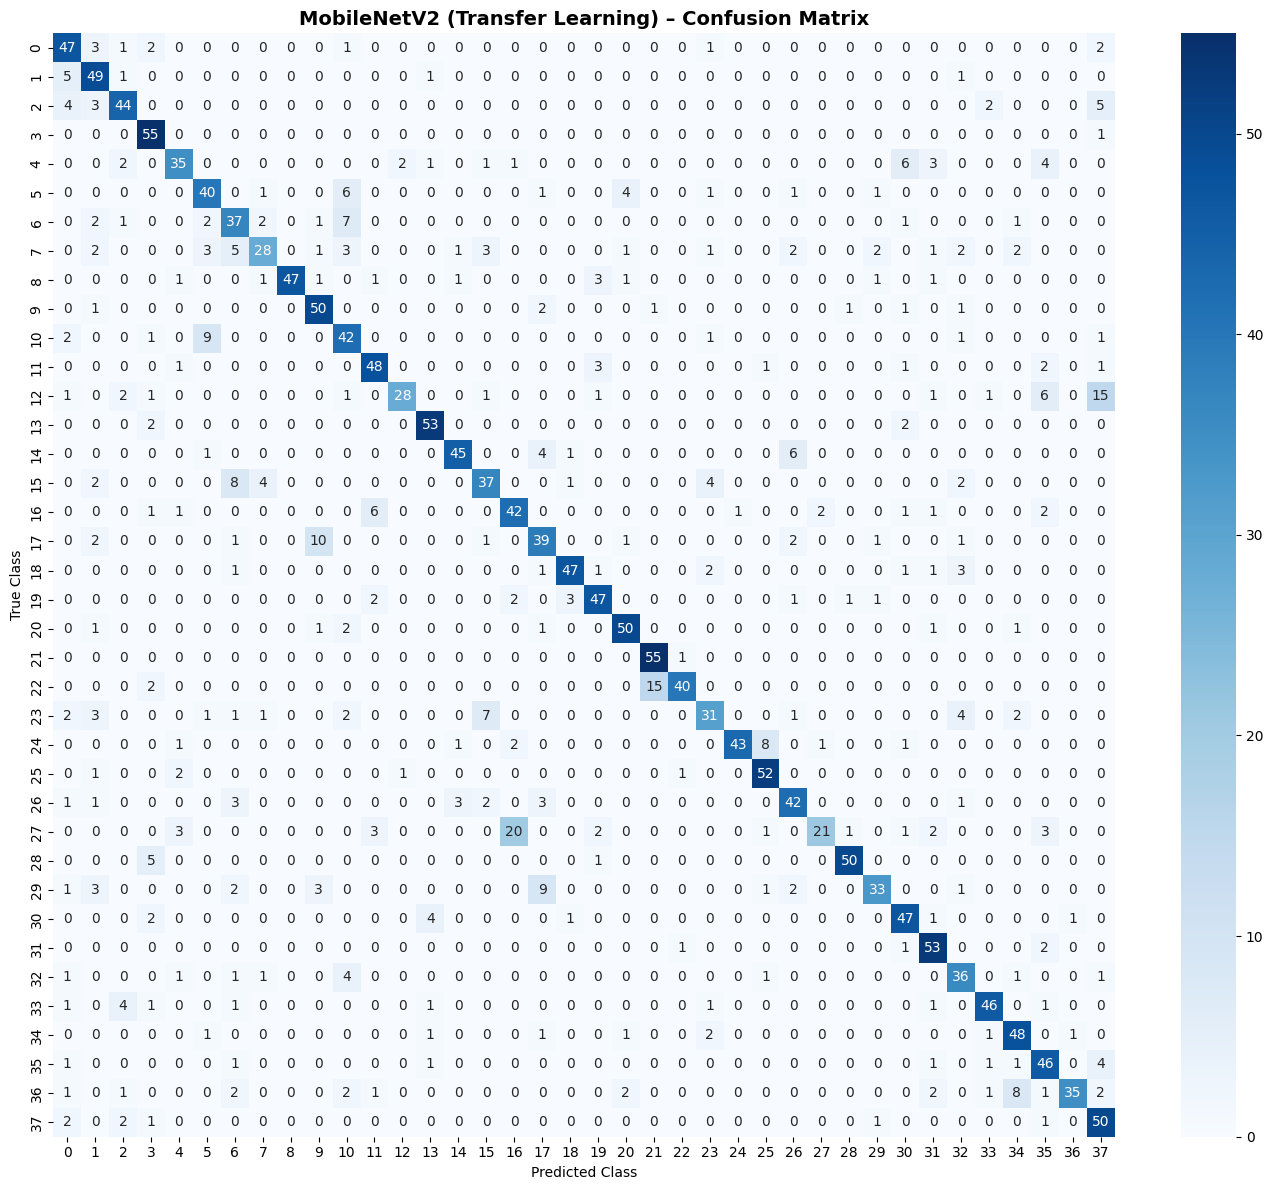

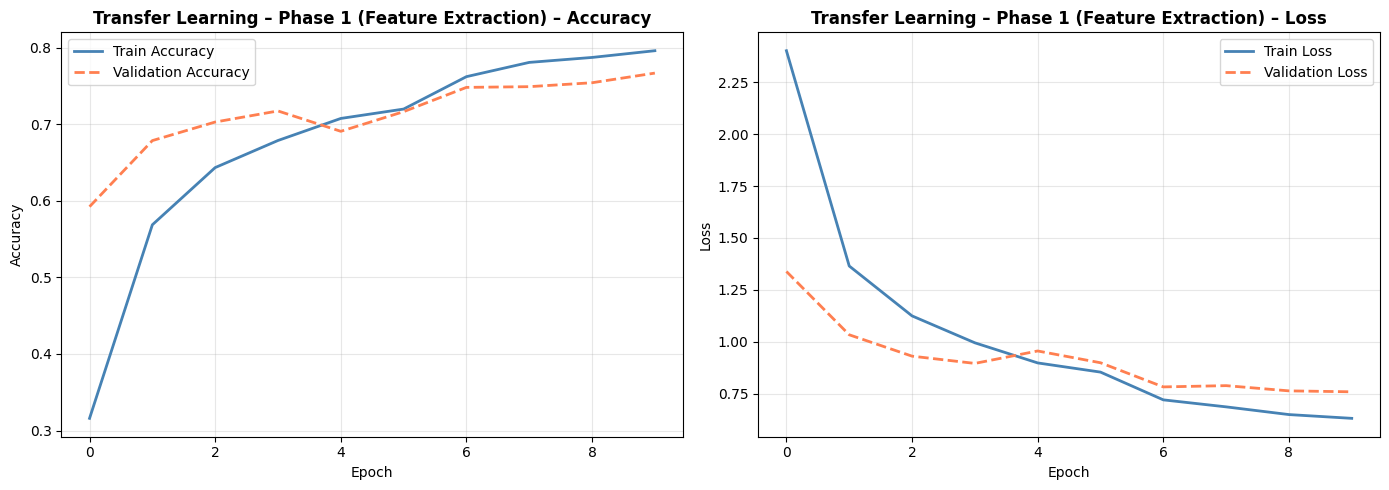

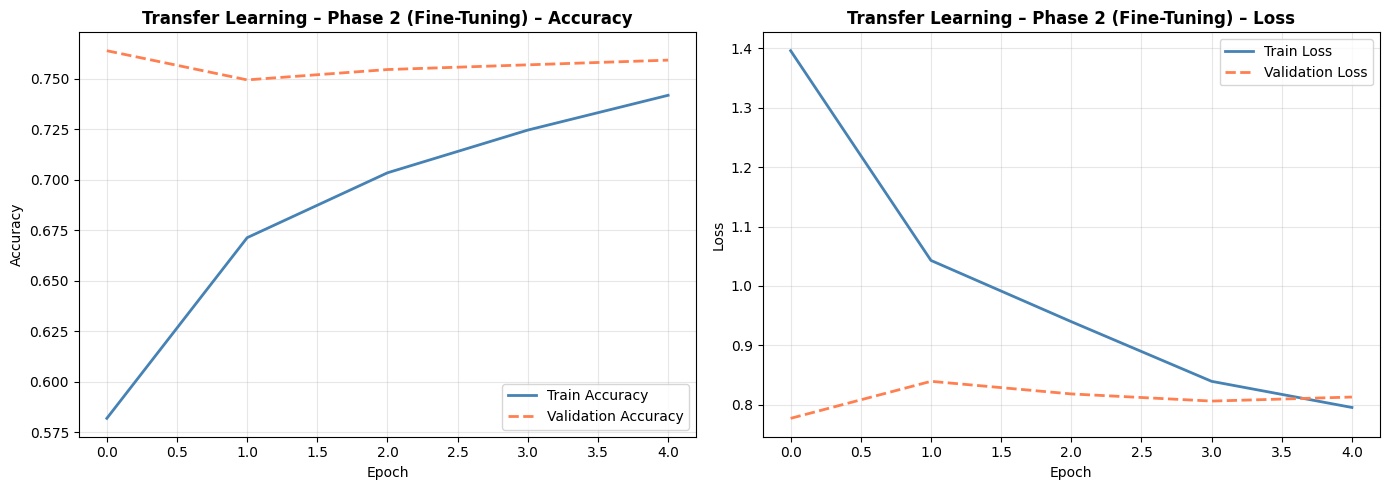

In [ ]:
y_true_tl, y_pred_tl, acc_tl = evaluate_model(
    tl_model_phase1, tl_val_gen, 'MobileNetV2 (Transfer Learning)')

# Plot TL training history
plot_history(history_tl_p1, title='Transfer Learning – Phase 1 (Feature Extraction)',
             save_name='tl_phase1_history.png')
plot_history(history_tl_p2, title='Transfer Learning – Phase 2 (Fine-Tuning)',
             save_name='tl_phase2_history.png')


## Section 6: Final Comparison – All Models


Model                                 Val Accuracy     Train Time
Baseline CNN                                71.69%         695.2s
Deep CNN (Adam)                             71.74%         773.0s
Deep CNN (SGD)                              70.71%         713.8s
Deep CNN (No Dropout – Ablation)            74.91%            N/A
MobileNetV2 (Transfer Learning)             76.40%        1163.6s


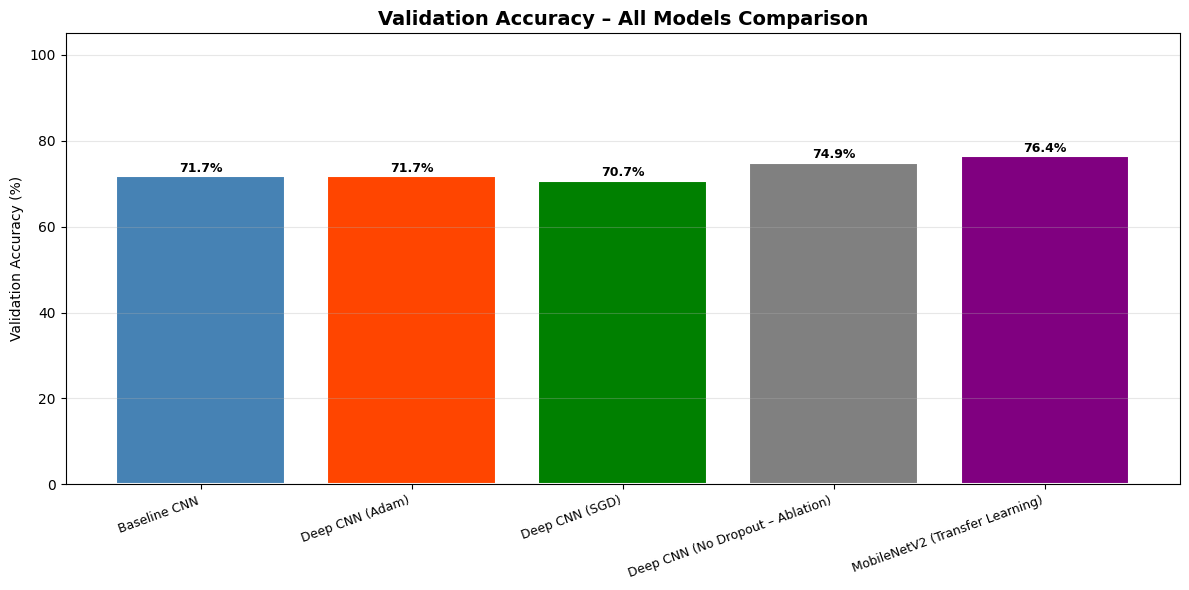

In [ ]:
# =====================================================================
# FINAL COMPARISON TABLE
# =====================================================================
model_results = {
    'Baseline CNN'                    : (acc_base,        time_base),
    'Deep CNN (Adam)'                 : (acc_deep_adam,   time_deep_adam),
    'Deep CNN (SGD)'                  : (acc_deep_sgd,    time_deep_sgd),
    'Deep CNN (No Dropout – Ablation)': (acc_ablation,    None),
    'MobileNetV2 (Transfer Learning)' : (acc_tl,          time_tl_p1 + time_tl_p2),
}

print('\n' + '='*68)
print(f'{"Model":<35} {"Val Accuracy":>14} {"Train Time":>14}')
print('='*68)
for name, (acc, t) in model_results.items():
    t_str = f'{t:.1f}s' if t else 'N/A'
    print(f'{name:<35} {acc*100:>13.2f}% {t_str:>14}')
print('='*68)

# Bar chart comparison
names = list(model_results.keys())
accs  = [v[0]*100 for v in model_results.values()]
colors= ['steelblue', 'orangered', 'green', 'gray', 'purple']

plt.figure(figsize=(12, 6))
bars = plt.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.title('Validation Accuracy – All Models Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 7: Predict on Your 3 Provided Test Images

Test images found: 3
  /content/drive/MyDrive/AI FINAL ASSESSMENT/Test/20180625_203333.jpg
  /content/drive/MyDrive/AI FINAL ASSESSMENT/Test/20180625_230047.jpg
  /content/drive/MyDrive/AI FINAL ASSESSMENT/Test/20180701_194331.jpg


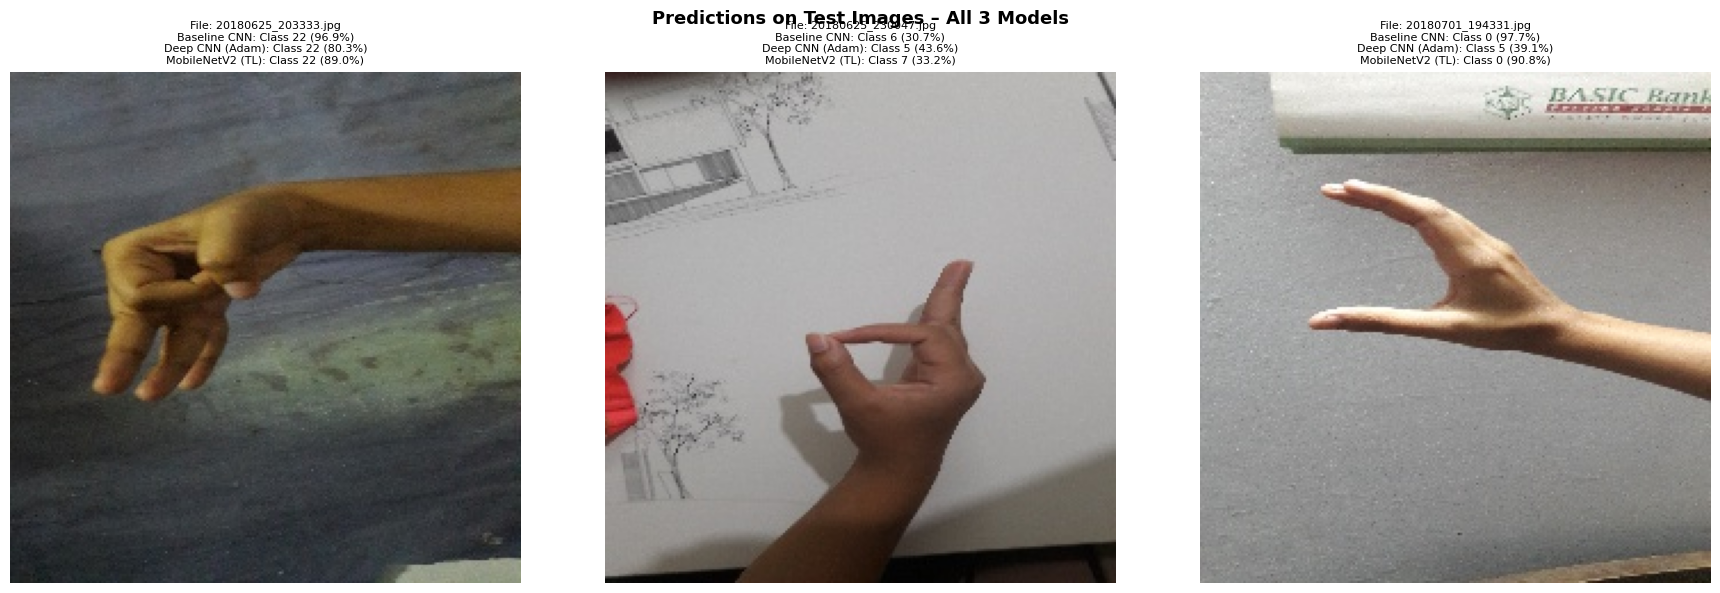

In [ ]:
# Section 7 - Predict on Test Images using all 3 models
all_test_images = collect_test_images(TEST_DIR, max_images=9)
print(f'Test images found: {len(all_test_images)}')
for p in all_test_images:
    print(f'  {p}')

def predict_all_models(img_path, models_dict):
    results = {}
    for name, (model, size) in models_dict.items():
        img_input = keras_image.load_img(img_path, target_size=(size, size))
        img_arr   = keras_image.img_to_array(img_input) / 255.0
        img_arr   = np.expand_dims(img_arr, axis=0)
        pred      = model.predict(img_arr, verbose=0)
        results[name] = (int(np.argmax(pred)), float(np.max(pred)*100))
    return results

models_to_test = {
    'Baseline CNN'    : (baseline_model,  IMG_HEIGHT),
    'Deep CNN (Adam)' : (deep_model,      IMG_HEIGHT),
    'MobileNetV2 (TL)': (tl_model_phase1, TL_IMG_SIZE),
}

n      = len(all_test_images)
n_cols = min(3, n)
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
axes = np.array(axes).flatten()

for idx, img_path in enumerate(all_test_images):
    img_display = keras_image.load_img(img_path)
    results     = predict_all_models(img_path, models_to_test)

    axes[idx].imshow(img_display)
    title_lines = [f'File: {os.path.basename(img_path)}']
    for mname, (cls, conf) in results.items():
        title_lines.append(f'{mname}: Class {cls} ({conf:.1f}%)')
    axes[idx].set_title('\n'.join(title_lines), fontsize=8)
    axes[idx].axis('off')

for idx in range(len(all_test_images), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Predictions on Test Images – All 3 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_image_predictions.png', dpi=150, bbox_inches='tight')
plt.show()




## Section 8: Save Models

In [ ]:
# Save all trained models
baseline_model.save('baseline_cnn.h5')
deep_model.save('deep_cnn_adam.h5')
deep_model_sgd.save('deep_cnn_sgd.h5')
tl_model_phase1.save('mobilenetv2_finetuned.h5')

print('All models saved successfully!')
print('  - baseline_cnn.h5')
print('  - deep_cnn_adam.h5')
print('  - deep_cnn_sgd.h5')
print('  - mobilenetv2_finetuned.h5')

All models saved successfully!
  - baseline_cnn.h5
  - deep_cnn_adam.h5
  - deep_cnn_sgd.h5
  - mobilenetv2_finetuned.h5
